In [1]:
!pip install pandas numpy matplotlib seaborn nltk wordcloud scikit-learn joblib

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords

from wordcloud import WordCloud

import os

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
os.makedirs("charts", exist_ok=True)

print("Folder Created Successfully")

Folder Created Successfully


In [4]:
df = pd.read_csv("zomato_reviews.csv")

df.head()

,Index,Name,Overall_Rating,Cuisine,Rate for two,City,Review
0,0,Oliver Brown,3.9,"Cafe, Coffee, Shake, Juices, Beverages, Waffle...",500,ahmedabad,Been to this place 3-4 times. Prakash is alway...
1,1,Oliver Brown,3.9,"Cafe, Coffee, Shake, Juices, Beverages, Waffle...",500,ahmedabad,I recently visited Oliver Brown on a weekend f...
2,2,Crush Coffee,3,"Cafe, Shake, Beverages, Desserts",600,ahmedabad,Very watery ans thin shake
3,3,The Mohalla,3.8,Cafe,550,ahmedabad,it was not cheese burst pizza.. only cheeze wa...
4,4,The Mohalla,3.8,Cafe,550,ahmedabad,"Yammi.,....test burger is best I love 💗 this B..."


In [5]:
print("Rows & Columns:", df.shape)

df.info()

Rows & Columns: (775, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 775 entries, 0 to 774
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Index           775 non-null    int64 
 1   Name            775 non-null    object
 2   Overall_Rating  775 non-null    object
 3   Cuisine         775 non-null    object
 4   Rate for two    775 non-null    object
 5   City            775 non-null    object
 6   Review          775 non-null    object
dtypes: int64(1), object(6)
memory usage: 42.5+ KB


In [6]:
df.isnull().sum()

,0
Index,0
Name,0
Overall_Rating,0
Cuisine,0
Rate for two,0
City,0
Review,0


In [7]:
df = df[['Name','Overall_Rating','Review']]

df.head()

,Name,Overall_Rating,Review
0,Oliver Brown,3.9,Been to this place 3-4 times. Prakash is alway...
1,Oliver Brown,3.9,I recently visited Oliver Brown on a weekend f...
2,Crush Coffee,3,Very watery ans thin shake
3,The Mohalla,3.8,it was not cheese burst pizza.. only cheeze wa...
4,The Mohalla,3.8,"Yammi.,....test burger is best I love 💗 this B..."


In [9]:
df['Overall_Rating'].head(20)

,Overall_Rating
0,3.9
1,3.9
2,3
3,3.8
4,3.8
5,4.3
6,4.3
7,3.7
8,4.8
9,4.1


In [10]:
df['Overall_Rating'].dtype

dtype('O')

In [11]:
df['Overall_Rating'] = pd.to_numeric(
    df['Overall_Rating'],
    errors='coerce'
)

In [12]:
df = df.dropna(subset=['Overall_Rating'])

In [13]:
def get_sentiment(rating):

    if rating >= 4:
        return "Positive"

    elif rating >= 3:
        return "Neutral"

    else:
        return "Negative"

df['Sentiment'] = df['Overall_Rating'].apply(get_sentiment)

df.head()

,Name,Overall_Rating,Review,Sentiment
0,Oliver Brown,3.9,Been to this place 3-4 times. Prakash is alway...,Neutral
1,Oliver Brown,3.9,I recently visited Oliver Brown on a weekend f...,Neutral
2,Crush Coffee,3.0,Very watery ans thin shake,Neutral
3,The Mohalla,3.8,it was not cheese burst pizza.. only cheeze wa...,Neutral
4,The Mohalla,3.8,"Yammi.,....test burger is best I love 💗 this B...",Neutral


In [14]:
df['Sentiment'].value_counts()

,count
Sentiment,
Neutral,375
Positive,255
Negative,28


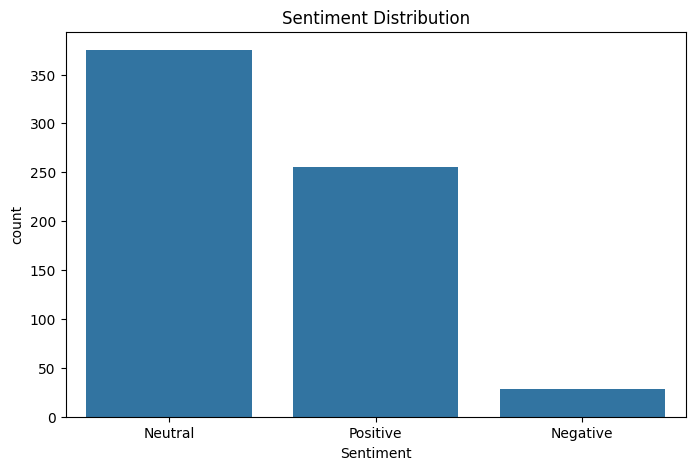

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Sentiment',
    data=df
)

plt.title("Sentiment Distribution")

plt.savefig(
    "charts/01_sentiment_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

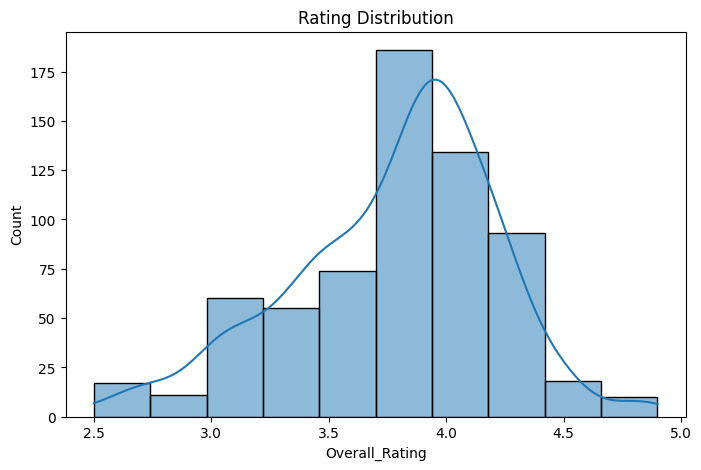

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Overall_Rating'],
    bins=10,
    kde=True
)

plt.title("Rating Distribution")

plt.savefig(
    "charts/02_rating_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

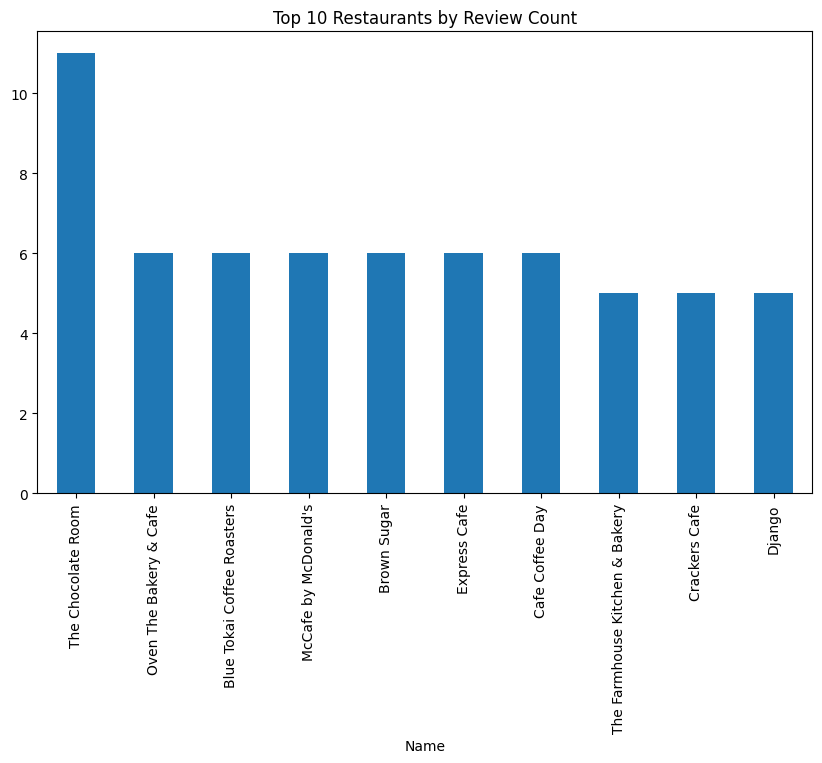

In [17]:
top_restaurants = (
    df['Name']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_restaurants.plot(kind='bar')

plt.title("Top 10 Restaurants by Review Count")

plt.savefig(
    "charts/03_top_restaurants.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [18]:
stop_words = set(stopwords.words('english'))

In [19]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+","",text)

    text = re.sub(r"\d+","",text)

    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [20]:
df['Clean_Review'] = df['Review'].apply(clean_text)

df[['Review','Clean_Review']].head()

,Review,Clean_Review
0,Been to this place 3-4 times. Prakash is alway...,place times prakash always sweet accommodating...
1,I recently visited Oliver Brown on a weekend f...,recently visited oliver brown weekend cup iced...
2,Very watery ans thin shake,watery ans thin shake
3,it was not cheese burst pizza.. only cheeze wa...,cheese burst pizza cheeze top happy pizza sent...
4,"Yammi.,....test burger is best I love 💗 this B...",yammitest burger best love 💗 bergerand fry als...


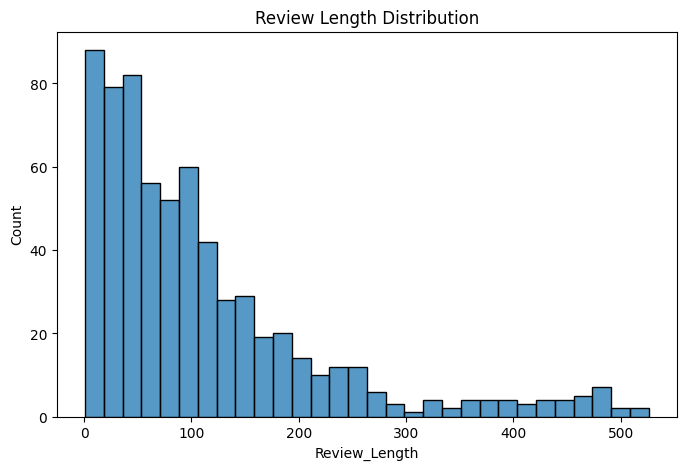

In [21]:
df['Review_Length'] = df['Clean_Review'].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(
    df['Review_Length'],
    bins=30
)

plt.title("Review Length Distribution")

plt.savefig(
    "charts/04_review_length.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [22]:
positive_text = " ".join(
    df[
        df['Sentiment']=='Positive'
    ]['Clean_Review']
)

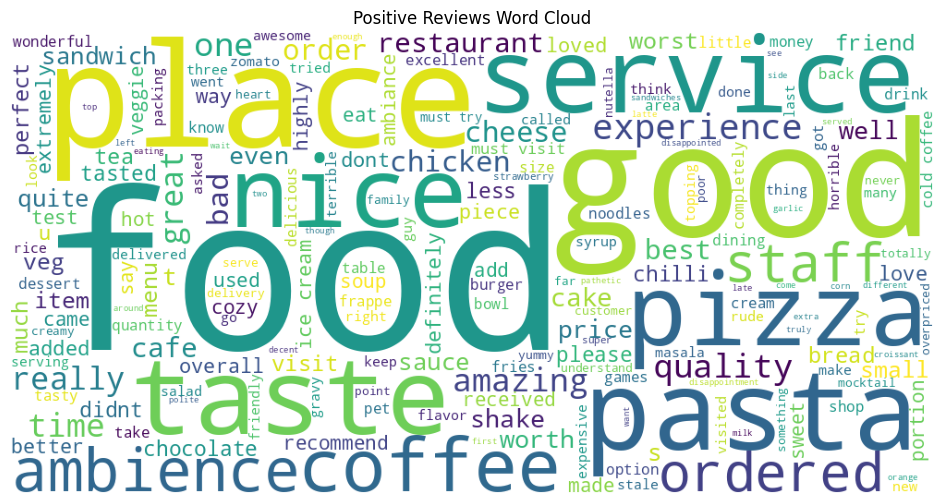

In [23]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Positive Reviews Word Cloud")

plt.savefig(
    "charts/05_positive_wordcloud.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [24]:
negative_text = " ".join(
    df[
        df['Sentiment']=='Negative'
    ]['Clean_Review']
)

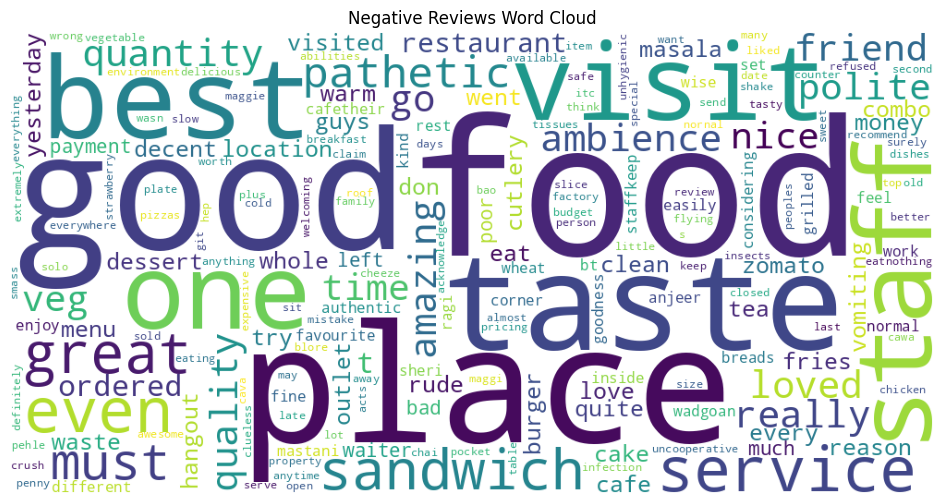

In [25]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Negative Reviews Word Cloud")

plt.savefig(
    "charts/06_negative_wordcloud.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [26]:
import os
import zipfile
from google.colab import files

# Folder containing charts
chart_folder = "charts"

# ZIP file name
zip_filename = "zomato_sentiment_analysis_charts.zip"

# Create ZIP
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files_in_folder in os.walk(chart_folder):
        for file in files_in_folder:
            file_path = os.path.join(root, file)
            zipf.write(file_path)

print(f"ZIP file created: {zip_filename}")

# Download ZIP
files.download(zip_filename)

ZIP file created: zomato_sentiment_analysis_charts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
df.to_csv("zomato_sentiment_final.csv", index=False)

In [28]:
from google.colab import files

files.download("zomato_sentiment_final.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
df.head()

,Name,Overall_Rating,Review,Sentiment,Clean_Review,Review_Length
0,Oliver Brown,3.9,Been to this place 3-4 times. Prakash is alway...,Neutral,place times prakash always sweet accommodating...,90
1,Oliver Brown,3.9,I recently visited Oliver Brown on a weekend f...,Neutral,recently visited oliver brown weekend cup iced...,259
2,Crush Coffee,3.0,Very watery ans thin shake,Neutral,watery ans thin shake,21
3,The Mohalla,3.8,it was not cheese burst pizza.. only cheeze wa...,Neutral,cheese burst pizza cheeze top happy pizza sent...,57
4,The Mohalla,3.8,"Yammi.,....test burger is best I love 💗 this B...",Neutral,yammitest burger best love 💗 bergerand fry als...,64
